In [20]:
using Pkg
include("../src/usadel_core.jl")
Pkg.activate("..")
Pkg.instantiate()
Pkg.precompile()
using Plots
using SparseArrays
using LinearAlgebra

  Activating project at `~/dev/julia/usadel_1D/usadel_1D`


In [10]:
#parameters and setup
Dn  = 2.0
Ds  = 2.0
ξn  = sqrt(Dn / 2.0) 
ξs  = sqrt(Ds / 2.0) 
Ln  = 20.0             
Ls  = 10.0             
dx  = 0.1              
Γin = 1e-3;


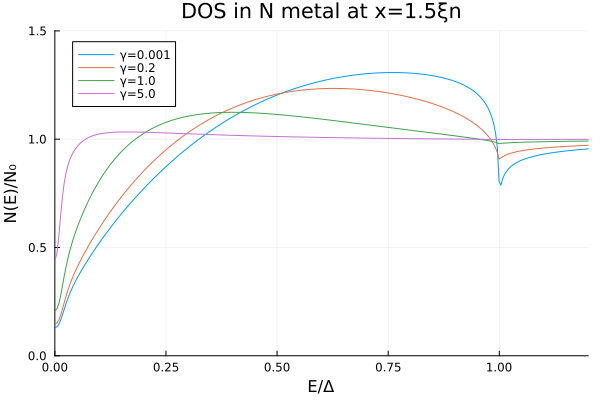

In [11]:

energies=collect(range(0.001,1.2,length=300))
x_eval=-1.5 
γ_vals = [0.001, 0.2, 1.0, 5.0]

plt = Plots.plot(xlabel="E/Δ", ylabel="N(E)/N₀",
           title="DOS in N metal at x=1.5ξn",
           ylims=(0, 1.5), xlims=(0, 1.2),
           legend=:topleft, lw=2)

for γ in γ_vals
    σs = 1.0
    σn = γ #* ξn / ξs    # from γ = σn*ξs/σs*ξn
    p_γ = setup_simulation_NS(Ln, Ls, dx, 0.0, Γin, σn, σs, Dn, Ds)
    dos, idx = compute_DOS(energies, p_γ, x_eval)
    plot!(plt, energies, dos, label="γ=$γ")
end

display(plt)

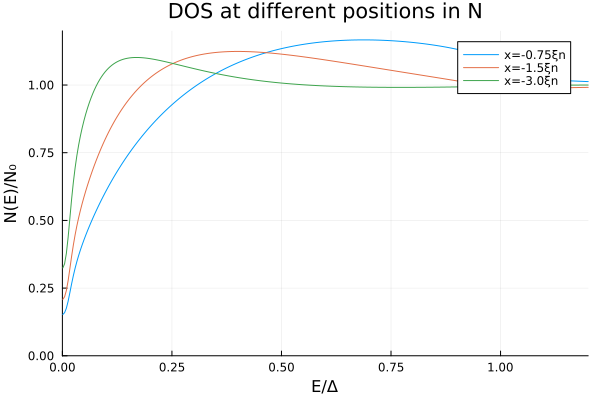

In [12]:
x_positions = [-0.75, -1.5, -3.0]
plt4 = plot(xlabel="E/Δ", ylabel="N(E)/N₀",
            title="DOS at different positions in N",
            ylims=(0, 1.2), xlims=(0, 1.2),
            legend=:topright, lw=2)

p_fig4 = setup_simulation_NS(Ln, Ls, dx, 0.0, Γin, 1.0, 1.0, Dn, Ds)

for x in x_positions
    dos, _ = compute_DOS(energies, p_fig4, x)
    plot!(plt4, energies, dos, label="x=$(x)ξn")
end

display(plt4)

In [24]:
T = 0.1
Tc = 1.0
energies=collect(range(0.001,1.2,length=300))
x_eval=-1.5
p = setup_simulation_NS(Ln, Ls, dx, 0.0, Γin, 1.0, 1.0, Dn, Ds)
Δ_sc, theta = self_consistent_delta(p,T,Tc,150,100,1e-6,0.5)
p.Δ = Δ_sc./maximum(Δ_sc)
dos1, _ = compute_DOS(energies, p, x_eval);

Converged after 102 iterations with max Δ change of 8.923832941487575e-7


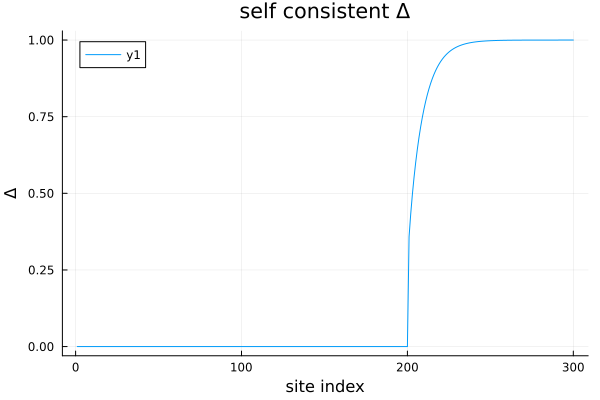

In [23]:
plt = Plots.plot(xlabel="site index", ylabel="Δ",
           title="self consistent Δ")

plot!(plt, 1:length(Δ_sc), Δ_sc./maximum(Δ_sc))

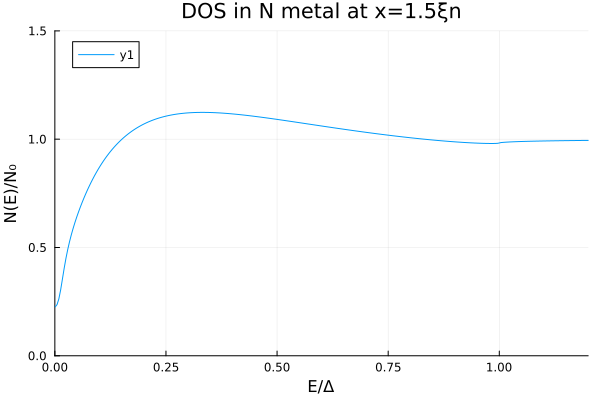

In [26]:
plt = Plots.plot(xlabel="E/Δ", ylabel="N(E)/N₀",
           title="DOS in N metal at x=1.5ξn",
           ylims=(0, 1.5), xlims=(0, 1.2),
           legend=:topleft, lw=2)

plot!(plt, energies, dos1)